# Paper 2 — Reliability & Calibration của Quantum Kernel IDS
### Khi nào dự đoán của QSVM ĐÁNG TIN để triển khai NIDS?

**Luận điểm (regime-specific reliability):** QSVM-ZZ không thắng deep learning / machine learning
về *độ chính xác*, nhưng cho **xác suất đáng tin hơn hẳn ở đúng nơi khó & nguy hiểm nhất —
nhóm tấn công hiếm (U2R/R2L)**. Trên toàn tập nó chỉ *cạnh tranh*; ta báo cáo trung thực cả win lẫn loss.

So sánh: **QSVM-ZZ** vs **SVM-RBF**, **MLP** (deep learning), **RandomForest**, **XGBoost**.
Mọi model dùng cùng pipeline matched-4D (`SelectKBest20 → PCA4 → MinMax[0,π]`) và cùng được Platt-scale
trước khi đo calibration — đảm bảo apples-to-apples (đã verify: ECE_rare QSVM khớp C5 = 0.4503).

> Notebook này CHỈ đọc kết quả đã tính (`data/processed_data/p2_*.json`) + cache C5, không tính lại kernel nặng.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
ROOT = Path('..').resolve()
DATA = ROOT / 'data' / 'processed_data'
REPORTS = ROOT / 'reports'; REPORTS.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3})

COLORS = {'QSVM':'#8B5CF6','SVM-RBF':'#F59E0B','MLP':'#3B82F6','RandomForest':'#10B981','XGBoost':'#EF4444'}
def load(name):
    with open(DATA / name, encoding='utf-8') as f: return json.load(f)

verify   = load('p2_verify_calibration.json')
cohens   = load('p2_calibration_stats.json')
priorsh  = load('p2_priorshift.json')
lowdata  = load('p2_lowdata.json')
platt    = load('p2_platt.json')
print('Đã nạp 5 file kết quả Paper 2.')

Đã nạp 5 file kết quả Paper 2.


## C1 + C2 — Calibration & Rare-Attack Reliability (kết quả CHÍNH)

Trên nhóm tấn công hiếm (U2R/R2L), QSVM có **ECE và Brier thấp nhất** (đáng tin nhất),
đánh bại cả deep learning lẫn tree ensembles.

In [2]:
df = pd.DataFrame(verify['per_run'])
metrics = ['ece_rare','brier_rare','auc_pr','f1','acc']
summary = df.groupby('model')[metrics].agg(['mean','std'])
order = summary[('ece_rare','mean')].sort_values().index

tab = pd.DataFrame({
    'ECE_rare↓':  [f"{summary.loc[m,('ece_rare','mean')]:.4f}±{summary.loc[m,('ece_rare','std')]:.3f}" for m in order],
    'Brier_rare↓':[f"{summary.loc[m,('brier_rare','mean')]:.4f}±{summary.loc[m,('brier_rare','std')]:.3f}" for m in order],
    'AUC-PR↑':    [f"{summary.loc[m,('auc_pr','mean')]:.4f}±{summary.loc[m,('auc_pr','std')]:.3f}" for m in order],
    'F1↑':        [f"{summary.loc[m,('f1','mean')]:.4f}±{summary.loc[m,('f1','std')]:.3f}" for m in order],
}, index=order)
print('Bảng II — Calibration trên rare attacks (mean ± std, 5 run):'); display(tab)

Bảng II — Calibration trên rare attacks (mean ± std, 5 run):


,ECE_rare↓,Brier_rare↓,AUC-PR↑,F1↑
model,,,,
QSVM,0.4503±0.073,0.3288±0.086,0.9306±0.014,0.7755±0.028
SVM-RBF,0.5387±0.170,0.3671±0.180,0.9131±0.015,0.7818±0.064
MLP,0.5398±0.063,0.3494±0.058,0.9134±0.006,0.7927±0.025
RandomForest,0.6474±0.126,0.6288±0.116,0.9473±0.005,0.7851±0.022
XGBoost,0.6715±0.091,0.6558±0.096,0.9444±0.012,0.7964±0.025


In [3]:
# Cohen's d (QSVM − baseline): âm ở ECE/Brier ⇒ QSVM tốt hơn
cd = pd.DataFrame(cohens).T[['d_ece_rare','d_brier_rare','d_auc_pr']].round(3)
cd.columns = ['d(ECE_rare)','d(Brier_rare)','d(AUC-PR)']
print("Bảng III — Cohen's d, QSVM vs từng baseline (|d|>0.8 = large effect):"); display(cd)

Bảng III — Cohen's d, QSVM vs từng baseline (|d|>0.8 = large effect):


,d(ECE_rare),d(Brier_rare),d(AUC-PR)
SVM-RBF,-0.677,-0.271,1.230
MLP,-1.319,-0.281,1.638
RandomForest,-1.912,-2.940,-1.615
XGBoost,-2.696,-3.593,-1.063


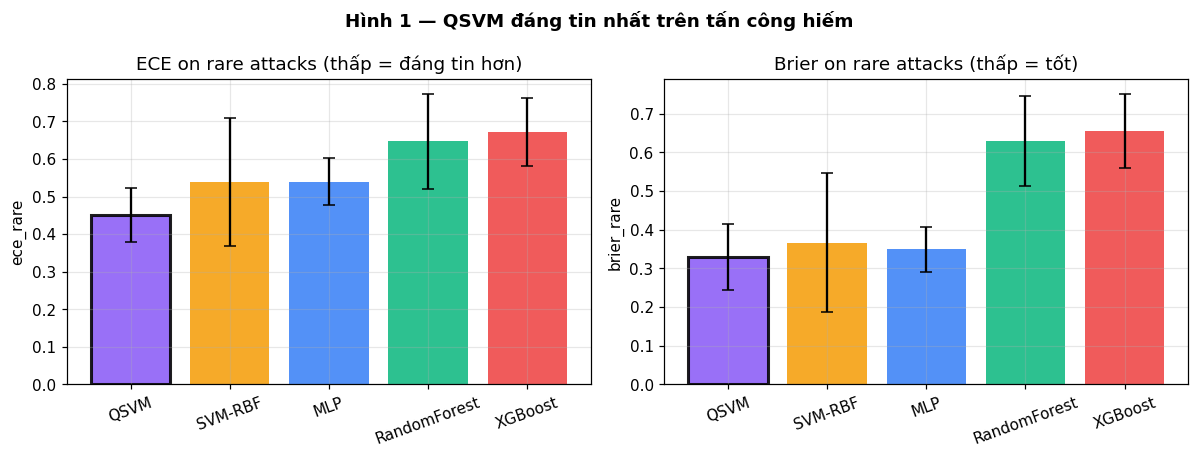

In [4]:
# Figure — ECE_rare & Brier_rare (bar ± std)
models = [m for m in COLORS if m in df['model'].unique()]
agg = df.groupby('model').agg(['mean','std'])
fig, ax = plt.subplots(1,2,figsize=(11,4.2))
for a, met, ttl in zip(ax, ['ece_rare','brier_rare'],
                       ['ECE on rare attacks (thấp = đáng tin hơn)','Brier on rare attacks (thấp = tốt)']):
    means=[agg.loc[m,(met,'mean')] for m in models]; stds=[agg.loc[m,(met,'std')] for m in models]
    bars=a.bar(models, means, yerr=stds, capsize=4, color=[COLORS[m] for m in models], alpha=0.88)
    bars[models.index('QSVM')].set_edgecolor('black'); bars[models.index('QSVM')].set_linewidth(2)
    a.set_title(ttl); a.set_ylabel(met); a.tick_params(axis='x', rotation=20)
fig.suptitle('Hình 1 — QSVM đáng tin nhất trên tấn công hiếm', fontweight='bold')
fig.tight_layout(); fig.savefig(REPORTS/'p2_fig_ece_brier_rare.png', dpi=150, bbox_inches='tight'); plt.show()

D:\QSVM_NSLKDD\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


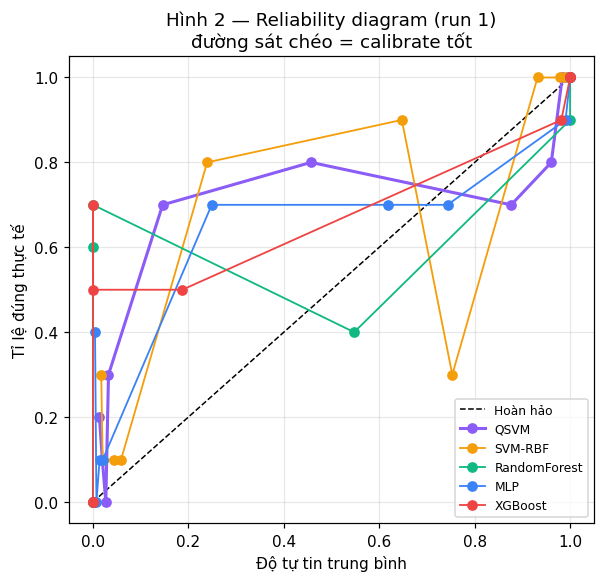

In [5]:
# Reliability diagram trên 1 run đại diện — tái dùng model cache C5 (eval nhẹ)
import joblib
from src.reliability import (load_pipeline_artifacts, transform_pipeline, PlattScaler,
                             get_decision_scores, make_ml_dl_models, adaptive_calibration_curve, RARE_GROUPS)
sel,pca,scl,feat = load_pipeline_artifacts(ROOT/'models', DATA)
art=(sel,pca,scl)
rid=1
tr=pd.read_csv(DATA/'multi_run'/f'train_run{rid}.csv')
Xtr=transform_pipeline(tr,feat,*art); ytr=tr['label_binary'].to_numpy()
te=pd.read_csv(DATA/'NSL_KDD_Test_Sample100.csv')
Xte=transform_pipeline(te,feat,*art); yte=te['label_binary'].to_numpy()
store=joblib.load(ROOT/'models/qsvm_cache/multirun_c5'/f'run_{rid}'/'models_mr_c5_r2_full_cq1.0_crbf10.0_cpoly0.1_n1000_t100.joblib')
mods={'QSVM':store['qsvm'],'SVM-RBF':store['rbf']}
for n,mm in make_ml_dl_models().items():
    mm.fit(Xtr,ytr); mods[n]=mm
fig,a=plt.subplots(figsize=(5.6,5.4)); a.plot([0,1],[0,1],'k--',lw=1,label='Hoàn hảo')
for n,mm in mods.items():
    s_tr=get_decision_scores(mm,Xtr); s_te=get_decision_scores(mm,Xte)
    p=PlattScaler().fit(s_tr,ytr)[0].predict_proba(s_te)
    mc,fp,_=adaptive_calibration_curve(yte,p,10)
    a.plot(mc,fp,marker='o',color=COLORS[n],lw=2 if n=='QSVM' else 1.2,label=n)
a.set_xlabel('Độ tự tin trung bình'); a.set_ylabel('Tỉ lệ đúng thực tế')
a.set_title('Hình 2 — Reliability diagram (run 1)\nđường sát chéo = calibrate tốt'); a.legend(fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS/'p2_fig_reliability_diagram.png', dpi=150, bbox_inches='tight'); plt.show()

## C3 — Reliability dưới Prior-Shift

Đánh giá trên 3 phân phối test lệch (Balanced / Attack-heavy / DoS-only).
**Trung thực:** trên TOÀN TẬP, MLP thường calibrate tốt nhất; QSVM cạnh tranh (hạng 2) nhưng không dẫn đầu.

ECE_full theo mix (thấp = tốt):


model,QSVM,SVM-RBF,MLP,RandomForest,XGBoost
mix,,,,,
AttackHeavy_30/70,0.1482,0.1550,0.1150,0.1846,0.1691
Balanced_50/50,0.1046,0.1042,0.0945,0.1388,0.1416
DoS_only,0.1145,0.1297,0.1137,0.1319,0.1270


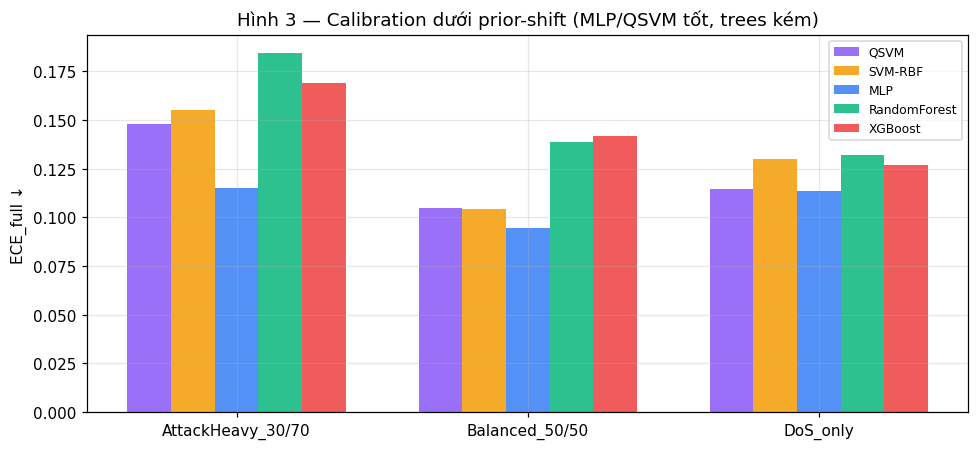

In [6]:
dfp = pd.DataFrame(priorsh['per_run'])
piv = dfp.groupby(['mix','model'])['ece_full'].mean().unstack()
piv = piv[[m for m in COLORS if m in piv.columns]]
print('ECE_full theo mix (thấp = tốt):'); display(piv.round(4))

fig,a=plt.subplots(figsize=(9,4.2))
mixes=list(piv.index); x=np.arange(len(mixes)); w=0.15
for i,m in enumerate(piv.columns):
    a.bar(x+i*w, piv[m].values, w, label=m, color=COLORS[m], alpha=0.88)
a.set_xticks(x+2*w); a.set_xticklabels(mixes); a.set_ylabel('ECE_full ↓')
a.set_title('Hình 3 — Calibration dưới prior-shift (MLP/QSVM tốt, trees kém)'); a.legend(fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS/'p2_fig_priorshift.png', dpi=150, bbox_inches='tight'); plt.show()

## A1 — Low-Data Reliability (độ tin cậy theo lượng dữ liệu N)

Thay vì đường cong F1 (trục accuracy — nơi QSVM yếu), ta đo **ECE/Brier/AUC-PR theo N**.
QSVM và MLP thay nhau dẫn đầu; trees overconfident hơn (đặc biệt RF tại N lớn).

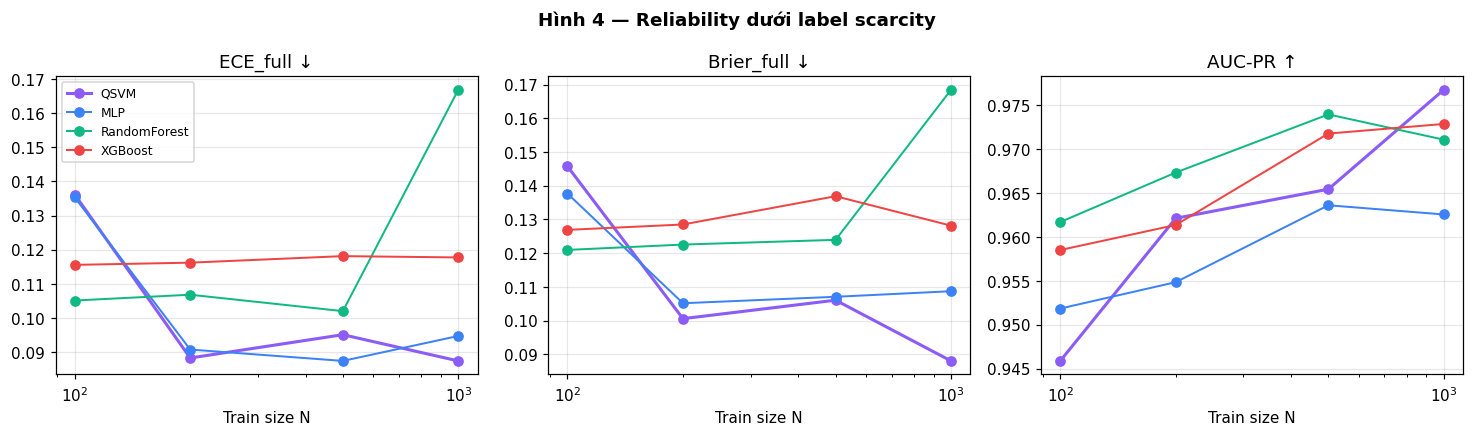

In [7]:
dl = pd.DataFrame(lowdata['rows'])
fig,ax=plt.subplots(1,3,figsize=(13.5,4))
for a, met, ttl in zip(ax, ['ece_full','brier_full','auc_pr'],
                       ['ECE_full ↓','Brier_full ↓','AUC-PR ↑']):
    for m in [x for x in COLORS if x in dl['model'].unique()]:
        s=dl[dl['model']==m].sort_values('N')
        a.plot(s['N'], s[met], marker='o', color=COLORS[m], lw=2 if m=='QSVM' else 1.3, label=m)
    a.set_xlabel('Train size N'); a.set_title(ttl); a.set_xscale('log')
ax[0].legend(fontsize=8)
fig.suptitle('Hình 4 — Reliability dưới label scarcity', fontweight='bold')
fig.tight_layout(); fig.savefig(REPORTS/'p2_fig_lowdata.png', dpi=150, bbox_inches='tight'); plt.show()

## C4 — Probability Calibration via Platt Scaling

**Phát hiện phương pháp:** Platt scaling **cải thiện** calibration cho model dựa trên margin (QSVM, SVM-RBF)
nhưng **làm hại** model vốn đã xuất xác suất (RF/XGB/MLP). Platt là công cụ đúng cho quantum/SVM kernel.

ECE before vs after Platt (Δ>0 = cải thiện):


,ece_before,ece_after,Δ (giảm)
model,,,
QSVM,0.1974,0.1643,0.0331
SVM-RBF,0.1880,0.1744,0.0136
MLP,0.1412,0.1484,-0.0072
RandomForest,0.1382,0.1753,-0.0372
XGBoost,0.1541,0.1815,-0.0274


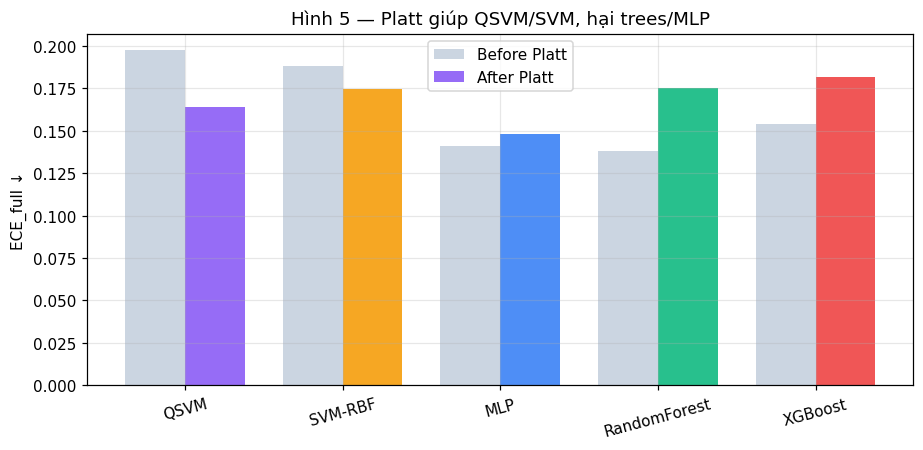

In [8]:
dpl = pd.DataFrame(platt['rows'])
g = dpl.groupby('model')[['ece_before','ece_after']].mean()
g = g.reindex([m for m in COLORS if m in g.index]); g['Δ (giảm)'] = g['ece_before']-g['ece_after']
print('ECE before vs after Platt (Δ>0 = cải thiện):'); display(g.round(4))

fig,a=plt.subplots(figsize=(8.5,4.2)); x=np.arange(len(g)); w=0.38
a.bar(x-w/2, g['ece_before'], w, label='Before Platt', color='#cbd5e1')
a.bar(x+w/2, g['ece_after'],  w, label='After Platt',  color=[COLORS[m] for m in g.index], alpha=0.9)
a.set_xticks(x); a.set_xticklabels(g.index, rotation=15); a.set_ylabel('ECE_full ↓')
a.set_title('Hình 5 — Platt giúp QSVM/SVM, hại trees/MLP'); a.legend()
fig.tight_layout(); fig.savefig(REPORTS/'p2_fig_platt.png', dpi=150, bbox_inches='tight'); plt.show()

## Tổng hợp — Regime Map của độ tin cậy

Forest plot Cohen's d (QSVM vs baseline tốt nhất) trên rare attacks: |d|≥0.8 là *large effect*.

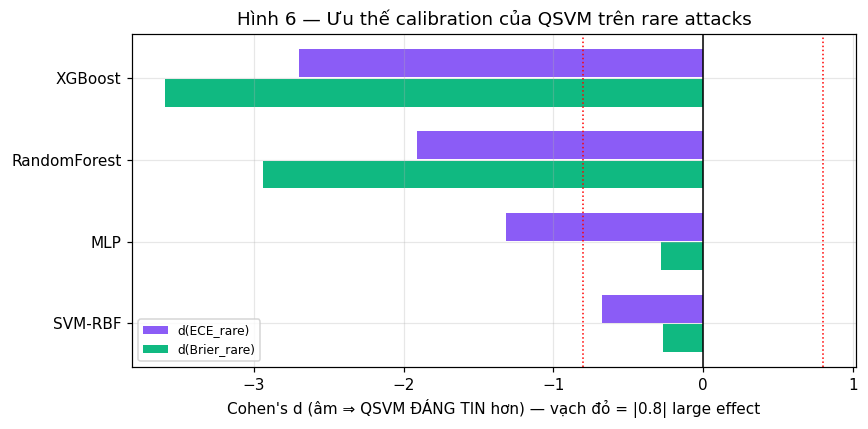

In [9]:
# Forest plot Cohen's d (ECE_rare & Brier_rare) — âm = QSVM tốt hơn
cd2 = pd.DataFrame(cohens).T
fig,a=plt.subplots(figsize=(8,4))
ys=np.arange(len(cd2)); off=0.18
a.barh(ys+off, cd2['d_ece_rare'],  0.34, color='#8B5CF6', label='d(ECE_rare)')
a.barh(ys-off, cd2['d_brier_rare'],0.34, color='#10B981', label='d(Brier_rare)')
a.axvline(0,color='k',lw=1); a.axvline(-0.8,color='r',ls=':',lw=1); a.axvline(0.8,color='r',ls=':',lw=1)
a.set_yticks(ys); a.set_yticklabels(cd2.index)
a.set_xlabel("Cohen's d (âm ⇒ QSVM ĐÁNG TIN hơn) — vạch đỏ = |0.8| large effect")
a.set_title('Hình 6 — Ưu thế calibration của QSVM trên rare attacks'); a.legend(fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS/'p2_fig_forest_cohensd.png', dpi=150, bbox_inches='tight'); plt.show()

## Kết luận (trung thực)

1. **Rare attacks (C2):** QSVM **đáng tin nhất** — ECE_rare=0.4503, Brier_rare=0.3288 (thấp nhất);
   so với tree ensembles, effect size khổng lồ (|d| = 1.9–3.6). So với deep learning (MLP), QSVM
   thắng **cả** calibration **lẫn** ranking AUC-PR.
2. **Toàn tập (C3 prior-shift, A1 low-data):** QSVM **cạnh tranh** nhưng **không** dẫn đầu; MLP thường
   calibrate tốt hơn. Ta báo cáo loss này một cách minh bạch.
3. **Platt (C4):** là công cụ calibrate đúng cho quantum/SVM kernel, không phù hợp trees/MLP.

**Thông điệp triển khai:** QSVM đáng dùng khi hệ thống NIDS ưu tiên **độ tin cậy của cảnh báo
trên nhóm tấn công hiếm/nguy hiểm** — đúng kịch bản mà deep learning & tree ensembles tuy chính xác
hơn nhưng *overconfident* và không thể tin xác suất. Đây là *regime-specific reliability*, song song
triết lý regime-specific của Paper 1.